# 1. Κατεβάζουμε τα αρχεία

In [1]:
from gdown import download

download(id='10iQQcGN80wqRMjGeItnklsODP54hHydP', output='model_ferplus.pth', quiet=False)
download(id='1g56Vxvk506MV4mxf3489WI-KBgmKiRLw', output='angry.png', quiet=False)
download(id='1ej3OzvPL_Itck2v3Atln671l-RfrvCss', output='happy.png', quiet=False)
download(id='1-2C4lT5WdAXSleGOG0KHtTeYfyDonhJn', output='neutral.png', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10iQQcGN80wqRMjGeItnklsODP54hHydP
To: c:\Users\Odysseas\Desktop\Programming\Python\model_ferplus.pth
100%|██████████| 5.22M/5.22M [00:00<00:00, 9.64MB/s]
Downloading...
From: https://drive.google.com/uc?id=1g56Vxvk506MV4mxf3489WI-KBgmKiRLw
To: c:\Users\Odysseas\Desktop\Programming\Python\angry.png
100%|██████████| 15.3k/15.3k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1ej3OzvPL_Itck2v3Atln671l-RfrvCss
To: c:\Users\Odysseas\Desktop\Programming\Python\happy.png
100%|██████████| 7.18k/7.18k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1-2C4lT5WdAXSleGOG0KHtTeYfyDonhJn
To: c:\Users\Odysseas\Desktop\Programming\Python\neutral.png
100%|██████████| 5.85k/5.85k [00:00<00:00, 17.9MB/s]


'neutral.png'

# 2. Φορτώνουμε το μοντέλο

In [2]:
import torch
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

class ReshapeAndScale255(torch.nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x):
        if len(x.shape) == 2: x = x.unsqueeze(0)
        return ( x.unsqueeze(1) / 255 ).clamp(0,1)
model = torch.nn.Sequential(
    ReshapeAndScale255(),
    models.shufflenet_v2_x1_0(num_classes = 8)
)
model[1].conv1[0] = torch.nn.Conv2d(1, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
model[1].load_state_dict(torch.load('model_ferplus.pth', map_location=device))
model.eval()

emotion_labels = [
    "neutral",    # 0
    "happy",      # 1
    "surprise",   # 2
    "sad",        # 3
    "angry",      # 4
    "disgust",    # 5
    "fear",       # 6
    "contempt"    # 7
]

# 3. Φορτώνουμε τη φωτογραφία σαν torch.tensor και τις βοηθητικές συναρτήσεις

Μια φωτογραφία αντιστοιχεί σε ένα πίνακα με 112 γραμμές και 112 στήλες.
Κάθε τιμή του πίνακα είναι από 0 εώς 255

- **loadImage**: Φορτώνει μια εικόνα όταν της δοθεί το path του αρχείου.  
- **tensorToImage**: Μετατρέπει ένα PyTorch `Tensor` σε κανονική εικόνα


tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


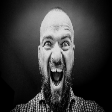

In [3]:
from PIL import Image
import numpy as np

def loadImage(filename):
    img = Image.open(filename).convert("L").resize( size=(112,112) )
    img_data = np.array(img).astype(np.float32)
    return torch.tensor(img_data)

def tensorToImage(tensor):
    return Image.fromarray(tensor.clamp(0,255).detach().reshape(112,112).numpy().astype(np.uint8))

Xoriginal = loadImage('angry.png')
print(Xoriginal)
tensorToImage(Xoriginal)

In [7]:
# Make happy image with minimal pixel changes
def make_happy_version(img, epsilon=2):
    """
    Targeted FGSM attack: push the image toward class 'happy'
    with minimal pixel changes.
    """
    x = img.clone().float().requires_grad_(True)
    target = torch.tensor([1])  # class index for 'happy'

    # Forward pass
    out = model(x.clamp(0,255).round())
    loss = torch.nn.functional.cross_entropy(out, target)

    # Backprop
    loss.backward()

    # Targeted FGSM: subtract gradient
    perturbed = x - epsilon * x.grad.sign()

    return perturbed.detach().clamp(0,255)

# 4. Αλλάζουμε τη φωτογραφία και βλέπουμε το καινούριο συναίσθημα

In [10]:
#TODO, παράδειγμα παρακάτω
# easy_first = loadImage('neutral.png')
# easy_second = loadImage('neutral.png')
# easy_second[85:87,40:70] = 255

# medium_first = loadImage('angry.png')
# medium_second = loadImage('angry.png')


# hard_first = loadImage('happy.png')
# hard_second = loadImage('happy.png')

easy_first = loadImage('neutral.png')
easy_second = make_happy_version(easy_first, epsilon=2)
medium_first = loadImage('angry.png')
medium_second = make_happy_version(medium_first, epsilon=2)

def make_not_happy(img, epsilon=2):
    x = img.clone().float().requires_grad_(True)
    target = torch.tensor([1])  # happy

    out = model(x.clamp(0,255).round())
    loss = torch.nn.functional.cross_entropy(out, target)

    loss.backward()

    # Untargeted attack: ADD gradient to move away from happy
    perturbed = x + epsilon * x.grad.sign()

    return perturbed.detach().clamp(0,255)

hard_first = make_not_happy(loadImage('happy.png'), epsilon=2)
hard_second = loadImage('happy.png')  # unchanged

Η συνάρτηση `compare_images` θα σας βοηθήσει να βλέπετε γρήγορα τις 2 εικόνες μαζί με τις προβλέψεις του μοντέλου.

**ΣΗΜΑΝΤΙΚΟ!!**

Πριν περάσουν στο μοντέλο, οι εικόνες στρογγυλοποιούνται στα κοντινότερα ακέραια pixel values. Πχ, εάν ένα pixel έχει τιμή 225.3, τότε γίνεται 225.

In [11]:
def compare_images(A, B):
    predictionA = model(A.clamp(0,255).round()).squeeze().softmax(-1)
    predictionB = model(B.clamp(0,255).round()).squeeze().softmax(-1)

    display(tensorToImage(A))
    print("predictions A:")
    for emotion, probability in zip(emotion_labels, predictionA):
        print(f"{probability*100:8.1f}% - {emotion}")

    emotionA = emotion_labels[predictionA.argmax()]
    print(f"emotion A = {emotionA}\n")

    display(tensorToImage(B))
    print("predictions B:")
    for emotion, probability in zip(emotion_labels, predictionB):
        print(f"{probability*100:8.1f}% - {emotion}")

    emotionB = emotion_labels[predictionB.argmax()]
    print(f"emotion B = {emotionB}\n")

    distance = (A.round() - B.round()).abs().sum().int().item()
    print(f"distance = {distance}")


#compare_images(easy_first, easy_second)

In [ ]:
compare_images(easy_first, easy_second)
compare_images(medium_first, medium_second)
compare_images(hard_first, hard_second)

# 5. Αποθήκευση Απαντήσεων για υποβολή στο site

In [ ]:
import json

def toList(tensor):
    return tensor.clamp(0,255).round().int().tolist()

answers = {
    "easy": {
        "first": toList(easy_first),
        "second": toList(easy_second)
    },
    "medium": {
        "second": toList(medium_second),
    },
    "hard": {
        "first": toList(hard_first),
    }
}
with open("answers.json", "w") as f:
    json.dump(answers, f)